# 06 - Foundation model

Forecasts with **Amazon Chronos**, a pretrained foundation model, against the benchmarks, SARIMAX and the feature-based model.

## How the model is used

| Aspect | Choice |
|---|---|
| Model | `amazon/chronos-bolt-small` (47.7M parameters) |
| Mode | **Zero-shot**, no fitting or fine-tuning |
| Covariates | **None**, Chronos is univariate |
| Evaluation | Rolling origin, 24-hour horizon, final 14 days |

**Why Chronos.** TimeGPT needs an API key and a network call per forecast, which would stop the pipeline running from a fresh clone. Chronos runs locally from open weights.

**Zero-shot** means the published weights are used as-is. The only thing the model sees of this dataset is the context window at prediction time, so there's nothing fitted to leak. It also gets **no covariates**, so it works from strictly less information than SARIMAX or the feature model.

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

# Hugging Face renders download/load progress as Jupyter widgets,
# which do not display outside a live kernel and clutter the saved
# notebook. Turn them off before importing anything that uses them.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import backtest, config, data, evaluation, features, plotting
from appliance_energy.models import benchmarks, feature_models, foundation, sarimax

config.ensure_dirs()
hourly = data.load_hourly_data()
y = hourly[config.TARGET].asfreq("h")
train, test = data.train_test_split_series(y, test_steps=config.TEST_STEPS)

print("Train:", train.index.min(), "to", train.index.max())
print("Test: ", test.index.min(), "to", test.index.max())

Train: 2016-01-11 17:00:00 to 2016-05-13 18:00:00
Test:  2016-05-13 19:00:00 to 2016-05-27 18:00:00


In [2]:
t0 = time.time()
pipe = foundation.load_chronos(config.FOUNDATION_MODEL_NAME)
print(f"Loaded {config.FOUNDATION_MODEL_NAME} in {time.time() - t0:.1f}s")

n_params = sum(p.numel() for p in pipe.model.parameters())
print(f"Parameters: {n_params:,}")
print(f"Context window: {foundation.MAX_CONTEXT} steps")
print(f"Quantiles: {foundation.DEFAULT_QUANTILES} -> {foundation.INTERVAL_LABEL}")

Loaded amazon/chronos-bolt-small in 38.2s
Parameters: 47,718,016
Context window: 2048 steps
Quantiles: (0.1, 0.5, 0.9) -> 80% interval


## 1. Forecast the next 24 hours

The model receives the training history as context and predicts the next 24 hours.

In [3]:
h = config.HORIZON
forecast_24h = foundation.forecast_chronos(
    pipe, context=train.values, horizon=h, index=test.index[:h])

actual_24h = test.iloc[:h]
forecast_24h.round(2).head(12)

,foundation_model,lower,upper
date,,,
2016-05-13 19:00:00,174.800003,103.959999,307.329987
2016-05-13 20:00:00,120.139999,73.709999,229.869995
2016-05-13 21:00:00,87.089996,59.919998,169.250000
2016-05-13 22:00:00,71.180000,54.709999,126.430000
2016-05-13 23:00:00,60.150002,50.840000,100.690002
2016-05-14 00:00:00,55.360001,48.220001,86.989998
2016-05-14 01:00:00,56.070000,48.779999,86.000000
2016-05-14 02:00:00,52.630001,46.080002,82.889999
2016-05-14 03:00:00,50.889999,43.520000,83.830002


In [4]:
rmse_24h = evaluation.rmse(actual_24h, forecast_24h["foundation_model"])
mae_24h = evaluation.mae(actual_24h, forecast_24h["foundation_model"])
cov_24h = ((actual_24h >= forecast_24h["lower"]) &
           (actual_24h <= forecast_24h["upper"])).mean()

print(f"24-hour RMSE : {rmse_24h:.2f} Wh")
print(f"24-hour MAE  : {mae_24h:.2f} Wh")
print(f"Actuals inside the {foundation.INTERVAL_LABEL}: {cov_24h:.0%}")

24-hour RMSE : 35.87 Wh
24-hour MAE  : 25.61 Wh
Actuals inside the 80% interval: 100%


Saved figure to D:\UK ass\outputs\figures\06_foundation_24h_forecast.png


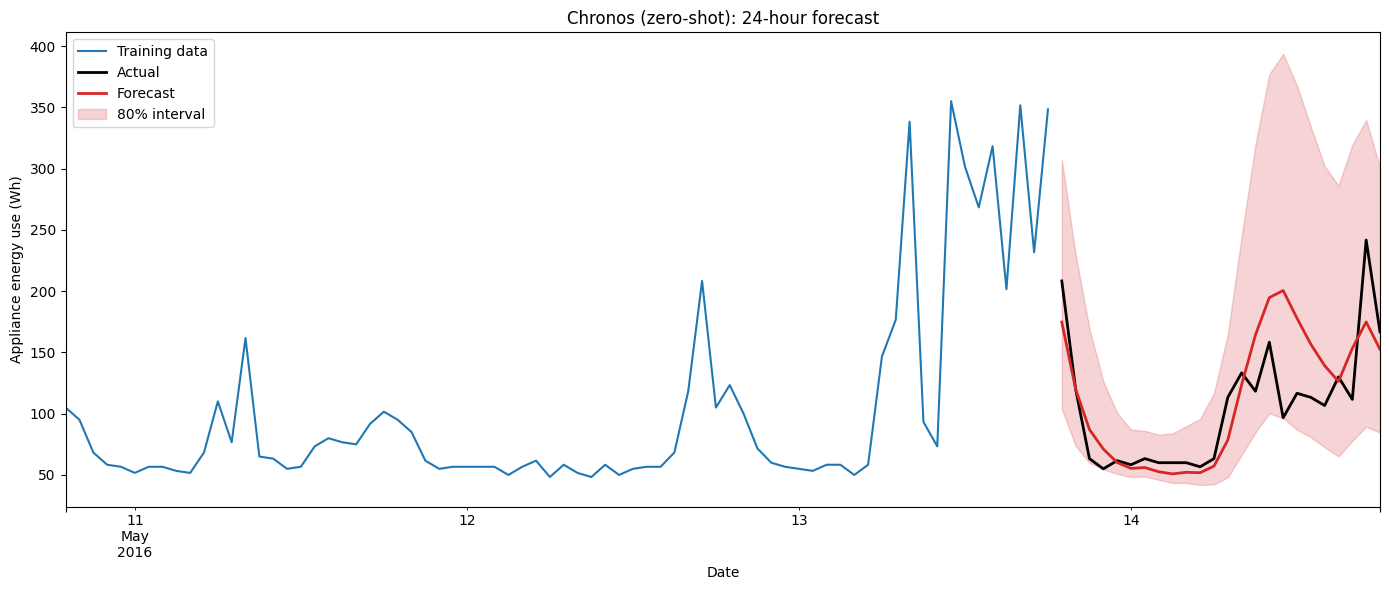

In [5]:
fig = plotting.plot_forecast_with_intervals(
    train, actual_24h, forecast_24h, forecast_col="foundation_model",
    context=72, alpha_label=foundation.INTERVAL_LABEL,
    title="Chronos (zero-shot): 24-hour forecast")
plotting.save_fig(fig, config.FIGURE_DIR / "06_foundation_24h_forecast.png")
plt.show()

## 2. Rolling evaluation over the full test period

Fourteen consecutive 24-hour forecasts, the same protocol used for every other model.

In [6]:
t0 = time.time()
foundation_roll = foundation.rolling_forecast_chronos(
    pipe, train, test, horizon=h)
print(f"14 rolling forecasts in {time.time() - t0:.1f}s")

metrics = evaluation.evaluate_forecast(
    "foundation_model", test, foundation_roll["foundation_model"], train)
pd.Series(metrics).to_frame("value").round(3)

14 rolling forecasts in 5.6s


,value
model,foundation_model
MAE,34.268018
RMSE,68.087302
MASE,0.641438
Bias,-16.569491


### Interval calibration

In [7]:
coverage = ((test >= foundation_roll["lower"]) &
            (test <= foundation_roll["upper"])).mean()
width = (foundation_roll["upper"] - foundation_roll["lower"]).mean()

print(f"{foundation.INTERVAL_LABEL} coverage: {coverage:.1%} (nominal 80%)")
print(f"Mean interval width: {width:.1f} Wh")

80% interval coverage: 83.6% (nominal 80%)
Mean interval width: 94.6 Wh


Why 80% and not 95%: Chronos-Bolt is only trained on quantiles 0.1 to 0.9. Asking for 0.05/0.95 doesn't fail, it quietly returns the 0.1/0.9 band labelled as 95%. So we ask for the widest band it actually supports. SARIMAX has no such limit. That's a real limitation of the foundation model, not of our setup.

## 3. Comparison against every other model

In [8]:
forecasts = {
    "mean": backtest.rolling_origin_forecast(
        benchmarks.mean_forecast, train, test, horizon=h),
    "naive": backtest.rolling_origin_forecast(
        benchmarks.naive_forecast, train, test, horizon=h),
    "drift": backtest.rolling_origin_forecast(
        benchmarks.drift_forecast, train, test, horizon=h),
    "seasonal_naive_daily": backtest.rolling_origin_forecast(
        benchmarks.seasonal_naive_forecast, train, test, horizon=h,
        seasonality=config.DAILY_PERIOD),
    "seasonal_naive_weekly": backtest.rolling_origin_forecast(
        benchmarks.seasonal_naive_forecast, train, test, horizon=h,
        seasonality=config.WEEKLY_PERIOD),
}

sarimax_roll = sarimax.rolling_forecast_sarimax(
    sarimax.load_model(), test, horizon=h)
forecasts["sarimax"] = sarimax_roll["sarimax"]

table = features.build_feature_table(hourly, horizon=h)
selection = json.load(open(config.FEATURE_MODEL_SELECTION_PATH))
split = feature_models.split_train_valid_test(
    table, feature_cols=selection["chosen_columns"])
forecasts["feature_model"] = feature_models.predict_feature_model(
    feature_models.load_model(), split["X_test"],
    index=split["y_test"].index, name="feature_model")

forecasts["foundation_model"] = foundation_roll["foundation_model"]

results = evaluation.evaluate_all(
    forecasts, test, train, seasonality=config.DAILY_PERIOD)
results.round(3)

,model,MAE,RMSE,MASE,Bias
0,foundation_model,34.268,68.087,0.641,-16.569
1,feature_model,35.384,62.033,0.662,-2.373
2,sarimax,36.255,64.736,0.679,-6.325
3,seasonal_naive_weekly,43.457,81.409,0.813,-13.160
4,seasonal_naive_daily,48.309,85.565,0.904,1.751
5,mean,50.258,74.938,0.941,-3.287
6,naive,85.551,110.390,1.601,50.977
7,drift,85.802,110.679,1.606,51.368


**Chronos is best on MAE and MASE, but not RMSE.** Section 4 unpacks that split. Its bias is also the most negative here, so it systematically under-forecasts.

Saved figure to D:\UK ass\outputs\figures\06_foundation_comparison.png


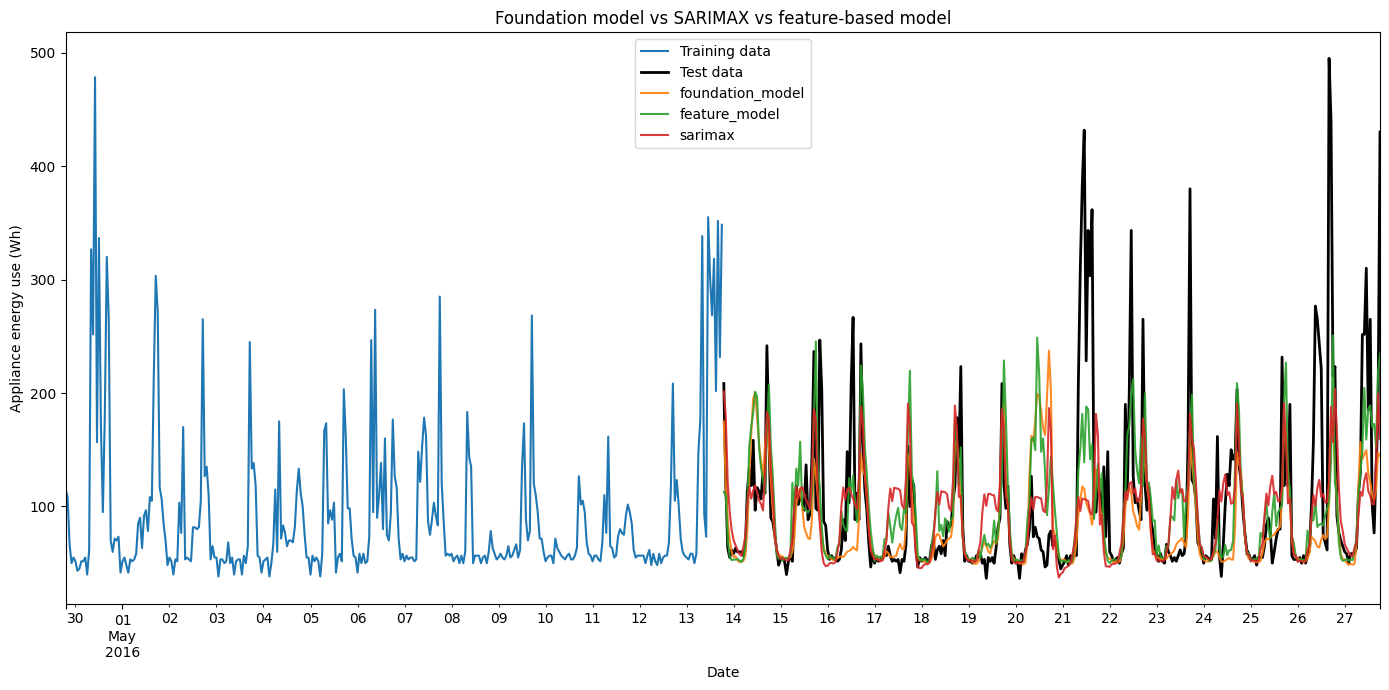

In [9]:
fig = plotting.plot_forecasts(
    train, test,
    pd.DataFrame({"actual": test,
                  "foundation_model": foundation_roll["foundation_model"],
                  "feature_model": forecasts["feature_model"],
                  "sarimax": forecasts["sarimax"]}),
    title="Foundation model vs SARIMAX vs feature-based model")
plotting.save_fig(fig, config.FIGURE_DIR / "06_foundation_comparison.png")
plt.show()

## 4. Where the foundation model wins and loses

Winning on MAE while losing on RMSE means the error *distribution* differs: RMSE squares errors, so it punishes a few large misses far more than many small ones.

In [10]:
err = pd.DataFrame({
    "foundation": (foundation_roll["foundation_model"] - test).abs(),
    "feature": (forecasts["feature_model"].reindex(test.index) - test).abs(),
    "sarimax": (forecasts["sarimax"] - test).abs(),
})

err.describe(percentiles=[0.5, 0.75, 0.9, 0.95]).round(2)

,foundation,feature,sarimax
count,336.00,336.00,336.00
mean,34.27,35.38,36.25
std,58.92,51.03,53.71
min,0.01,0.05,0.01
50%,9.80,14.74,15.90
75%,31.59,45.09,46.13
90%,108.50,91.93,79.96
95%,154.67,145.60,144.77
max,392.03,390.29,372.08


In [11]:
print(f"Foundation beats the feature model on "
      f"{100 * (err['foundation'] < err['feature']).mean():.0f}% of hours")

summary = pd.DataFrame({
    "median_abs_error": err.median(),
    "90th_pct_abs_error": err.quantile(0.9),
    "max_abs_error": err.max(),
}).round(2)
summary

Foundation beats the feature model on 56% of hours


,median_abs_error,90th_pct_abs_error,max_abs_error
foundation,9.80,108.50,392.03
feature,14.74,91.93,390.29
sarimax,15.90,79.96,372.08


Chronos has the **lowest median error** and models ordinary hours better than anything else, but the **largest tail errors**, missing evening peaks by more than the others. Low median wins for daily totals, low tail error matters for sizing a supply that covers peaks.

Saved figure to D:\UK ass\outputs\figures\06_error_by_step_ahead.png


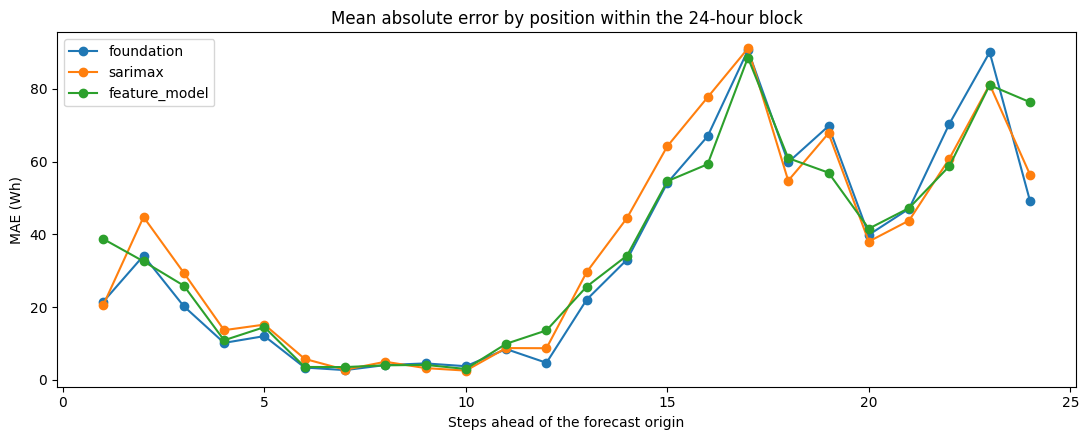

,foundation,sarimax,feature_model
step_ahead,,,
1,21.47,20.55,38.72
12,4.70,8.70,13.60
24,49.21,56.43,76.32


In [12]:
step = np.tile(np.arange(1, h + 1), len(test) // h)
by_step = pd.DataFrame({
    "step_ahead": step,
    "foundation": err["foundation"].values,
    "sarimax": err["sarimax"].values,
    "feature_model": err["feature"].values,
}).groupby("step_ahead").mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
by_step.plot(ax=ax, marker="o")
ax.set_title("Mean absolute error by position within the 24-hour block")
ax.set_ylabel("MAE (Wh)")
ax.set_xlabel("Steps ahead of the forecast origin")
fig.tight_layout()
plotting.save_fig(fig, config.FIGURE_DIR / "06_error_by_step_ahead.png")
plt.show()

by_step.loc[[1, 12, 24]].round(2)

**Read this carefully.** The test period is 14 aligned 24-hour blocks, so step position and hour of day are the same variable. The shape within one model tracks time-of-day difficulty, not decay with forecast distance.

Comparing between models at a fixed step is still valid. **Step 24 is the cleanest**, every model a full 24 hours ahead: Chronos 49.21, SARIMAX 56.43, feature model 76.32. Chronos leads at equal horizon as well as overall, though 14 observations per step is thin evidence.

## 5. Does a larger model help?

Zero-shot, same protocol, two model sizes.

In [13]:
size_rows = []
for model_name in ["amazon/chronos-bolt-tiny",
                   "amazon/chronos-bolt-small",
                   "amazon/chronos-bolt-base"]:
    p = foundation.load_chronos(model_name)

    t0 = time.time()
    roll = foundation.rolling_forecast_chronos(p, train, test, horizon=h)
    infer_s = time.time() - t0

    row = evaluation.evaluate_forecast(
        model_name.split("/")[-1], test, roll["foundation_model"], train)
    row["params_M"] = round(sum(q.numel() for q in p.model.parameters()) / 1e6, 1)
    row["inference_s"] = round(infer_s, 1)
    size_rows.append(row)

pd.DataFrame(size_rows).round(3)

,model,MAE,RMSE,MASE,Bias,params_M,inference_s
0,chronos-bolt-tiny,34.785,67.191,0.651,-14.073,8.7,1.8
1,chronos-bolt-small,34.268,68.087,0.641,-16.569,47.7,3.8
2,chronos-bolt-base,33.278,66.034,0.623,-16.969,205.3,18.7


Accuracy improves with size, but slowly: about 4% MASE for a **24x** jump in parameters. `base` is the best model in the project on every metric, including the RMSE `small` loses on.

The default is still `chronos-bolt-small`. `base` is around 1 GB to download, a real obstacle to running this repo from a fresh clone, for roughly 0.02 MASE. That's a deployment judgement, recorded here so the choice is visible.

## 6. What it costs

In [14]:
cost = pd.DataFrame([
    {"model": "seasonal naive (weekly)", "parameters": 0,
     "fitted_on_our_data": "no", "uses_covariates": "no",
     "needs_torch": "no"},
    {"model": "SARIMA(2,0,2)(0,1,1,24)", "parameters": 6,
     "fitted_on_our_data": "yes", "uses_covariates": "optional",
     "needs_torch": "no"},
    {"model": "random forest (13 features)", "parameters": "~400 trees",
     "fitted_on_our_data": "yes", "uses_covariates": "yes",
     "needs_torch": "no"},
    {"model": "Chronos-Bolt-small", "parameters": f"{n_params:,}",
     "fitted_on_our_data": "no (zero-shot)", "uses_covariates": "no",
     "needs_torch": "yes"},
])
cost

,model,parameters,fitted_on_our_data,uses_covariates,needs_torch
0,seasonal naive (weekly),0,no,no,no
1,"SARIMA(2,0,2)(0,1,1,24)",6,yes,optional,no
2,random forest (13 features),~400 trees,yes,yes,no
3,Chronos-Bolt-small,"47,718,016",no (zero-shot),no,yes


## 7. Save outputs

In [15]:
forecast_24h.to_csv(config.FORECAST_DIR / "foundation_24h_forecast.csv")
foundation_roll.to_csv(config.FOUNDATION_FORECAST_PATH)
results.to_csv(config.METRICS_DIR / "foundation_comparison.csv", index=False)
print("Saved foundation-model forecasts and metrics.")

Saved foundation-model forecasts and metrics.


## Summary

- **Chronos-Bolt-small, zero-shot and univariate, is the most accurate model on MAE and MASE**, beating everything else without being fitted to this data and without covariates.
- **It isn't best on RMSE.** Lowest median error, largest tail errors.
- **It under-forecasts**, with the most negative bias here.
- **The advantage survives the fair comparison** at step 24.
- **Bigger helps, but barely**: 24x the parameters for about 4% MASE.
- **The costs are real**: ~48M parameters and a torch dependency against six coefficients for SARIMAX, for a modest MASE gain and a worse RMSE.